In [0]:
# storage_account = "stlakehousebello"
# container = "healthcare"

# sas_token = "sv=2026-02-06&ss=b&srt=co&sp=rlx&se=2026-09-23T07:45:00Z&st=2026-09-23T04:25:00Z&spr=https&sig=7GfU8ntK0Lm5mvIG8AbRW2V8QZ3QII7g5vNvy8BLW%2BM%3D"

# spark.conf.set(
#     f"fs.azure.sas.{container}.{storage_account}.dfs.core.windows.net",
#     sas_token
# )

In [0]:
# base_path = (
#     "abfss://healthcare@"
#     "stlakehousebello.dfs.core.windows.net/"
# )

# display(dbutils.fs.ls(base_path))

In [0]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

print("Imports successful!")

Imports successful!


Load the Parquet

In [0]:
file_path = "/Volumes/workspace/default/openfda_ml/openfda_ml_features.parquet"

df = pd.read_parquet(file_path)

print(f"Rows: ", len(df))
print(f"Columns: ", len(df.columns))

display(df.head())

Rows:  1000
Columns:  13


safetyreportid,patientonsetage,patientonsetageunit,patientsex,reportercountry,reporterqualification,number_of_reactions,number_of_drugs,transmission_year,transmission_month,reporting_delay_days,target_serious,drug_reaction_ratio
5801206-7,26.0,801,1.0,CANADA,3.0,2,1,2009,1,186,1,0.5
10003300,77.0,801,2.0,US,5.0,4,1,2014,10,210,1,0.25
10003301,null,,2.0,US,5.0,2,1,2014,10,216,1,0.5
10003302,null,,1.0,US,5.0,1,1,2014,10,204,0,1.0
10003304,null,,2.0,US,1.0,1,9,2014,12,275,0,9.0


In [0]:
display(
    pd.DataFrame({
        "column": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "missing": df.isna().sum().values,
        "missing_pct": (df.isna().mean() * 100).round(2).values
    })
)

column,dtype,missing,missing_pct
safetyreportid,object,0,0.0
patientonsetage,float64,341,34.1
patientonsetageunit,object,0,0.0
patientsex,float64,4,0.4
reportercountry,object,0,0.0
reporterqualification,float64,7,0.7
number_of_reactions,int64,0,0.0
number_of_drugs,int64,0,0.0
transmission_year,int32,0,0.0
transmission_month,int32,0,0.0


Duplicate Check

In [0]:
print("Duplicate safety report IDS: ", df["safetyreportid"].duplicated().sum())
print("Duplicate rows: ", df.duplicated().sum())

Duplicate safety report IDS:  0
Duplicate rows:  0


Target distribution

In [0]:
target_counts = df["target_serious"].value_counts().sort_index()

print("Target distribution: ")
print(target_counts)

print("\nTarget percentage: ")
print((target_counts / len(df) * 100).round(2))

Target distribution: 
target_serious
0    546
1    454
Name: count, dtype: int64

Target percentage: 
target_serious
0    54.6
1    45.4
Name: count, dtype: float64


Define target and identifier

In [0]:
target = "target_serious"
identifier = "safetyreportid"

print("Target column:", target)
print("Identifier column: ", identifier)

Target column: target_serious
Identifier column:  safetyreportid


Build X and y

In [0]:
X = df.drop(columns=[target, identifier])
y = df[target]

print("Feature matrix shape: ", X.shape)
print("Target shape: ", y.shape)

print("\nFeatures used by the model: ")
for col in X.columns:
    print(" - ", col)

Feature matrix shape:  (1000, 11)
Target shape:  (1000,)

Features used by the model: 
 -  patientonsetage
 -  patientonsetageunit
 -  patientsex
 -  reportercountry
 -  reporterqualification
 -  number_of_reactions
 -  number_of_drugs
 -  transmission_year
 -  transmission_month
 -  reporting_delay_days
 -  drug_reaction_ratio


Preprocessing

In [0]:
display(df.dtypes)

safetyreportid            object
patientonsetage          float64
patientonsetageunit       object
patientsex               float64
reportercountry           object
reporterqualification    float64
number_of_reactions        int64
number_of_drugs            int64
transmission_year          int32
transmission_month         int32
reporting_delay_days       int64
target_serious             int64
drug_reaction_ratio      float64
dtype: object

safetyreportid            object
patientonsetage          float64
patientonsetageunit       object
patientsex               float64
reportercountry           object
reporterqualification    float64
number_of_reactions        int64
number_of_drugs            int64
transmission_year          int32
transmission_month         int32
reporting_delay_days       int64
target_serious             int64
drug_reaction_ratio      float64
dtype: object


In [0]:
categorical_features = X.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=["number"]
).columns.tolist()

print("Categorical features: ")
print(categorical_features)

print("\nNumerical features: ")
print(numerical_features)


Categorical features: 
['patientonsetageunit', 'reportercountry']

Numerical features: 
['patientonsetage', 'patientsex', 'reporterqualification', 'number_of_reactions', 'number_of_drugs', 'transmission_year', 'transmission_month', 'reporting_delay_days', 'drug_reaction_ratio']


In [0]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numerical_features),
    ("categorical", categorical_pipeline, categorical_features)
])

print("Preprocessor created.")

Preprocessor created.


Train/test Split

In [0]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print("Training rows: ", X_train.shape[0])
print("Testing rows: ", X_test.shape[0])

print("\nTraining target distribution: ")
print(y_train.value_counts())

print("\nTest target distribution: ")
print(y_test.value_counts())

Training rows:  800
Testing rows:  200

Training target distribution: 
target_serious
0    437
1    363
Name: count, dtype: int64

Test target distribution: 
target_serious
0    109
1     91
Name: count, dtype: int64


Build the baseline

In [0]:
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(
    strategy="most_frequent"
)

baseline_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", baseline)
])

baseline_pipeline.fit(X_train, y_train)

baseline_pred = baseline_pipeline.predict(X_test)

baseline_accuracy = accuracy_score(y_test, baseline_pred)
baseline_precision = precision_score(y_test, baseline_pred, zero_division=0)
baseline_recall = recall_score(y_test, baseline_pred, zero_division=0)
baseline_f1 = f1_score(y_test, baseline_pred, zero_division=0)

print("BASELINE MODEL")
print("=" * 50)
print(f"Accuracy : {baseline_accuracy:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall   : {baseline_recall:.4f}")
print(f"F1       : {baseline_f1:.4f}")

BASELINE MODEL
Accuracy : 0.5450
Precision: 0.0000
Recall   : 0.0000
F1       : 0.0000


XGBoost

In [0]:
# %pip install xgboost
import xgboost as xgb

print("XGBoost version: ", xgb.__version__)

XGBoost version:  3.4.1


In [0]:
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", xgb_model)
])

xgb_pipeline.fit(X_train, y_train)

print("XGBoost training complete")

XGBoost training complete


In [0]:
xgb_pred = xgb_pipeline.predict(X_test)
xgb_prob = xgb_pipeline.predict_proba(X_test)[:, 1]   # keep all rows (:) but grab only the second column (1) - Serious(Class 1)

accuracy = accuracy_score(y_test, xgb_pred)
precision = precision_score(y_test, xgb_pred, zero_division=0)
recall = recall_score(y_test, xgb_pred, zero_division=0)
f1 = f1_score(y_test, xgb_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, xgb_prob)
pr_auc = average_precision_score(y_test, xgb_prob)

print("XGBOOST MODEL")
print("=" * 50)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1       : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print(f"PR-AUC   : {pr_auc:.4f}")

XGBOOST MODEL
Accuracy : 0.7800
Precision: 0.7831
Recall   : 0.7143
F1       : 0.7471
ROC-AUC  : 0.8759
PR-AUC   : 0.8803


In [0]:
print(
    classification_report(
        y_test,
        xgb_pred,
        target_names=["Not Serious", "Serious"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

 Not Serious       0.78      0.83      0.81       109
     Serious       0.78      0.71      0.75        91

    accuracy                           0.78       200
   macro avg       0.78      0.77      0.78       200
weighted avg       0.78      0.78      0.78       200



In [0]:
cm = confusion_matrix(y_test, xgb_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Actual Not Serious", "Actual Serious"],
    columns=["Predicted Not Serious", "Predicted Serious"]
)

display(cm_df)

Predicted Not Serious,Predicted Serious
91,18
26,65


Compare baseline vs XGBoost

In [0]:
comparison = pd.DataFrame({
    "Model": ["Majority Baseline", "XGBoost"],
    "Accuracy": [
        baseline_accuracy,
        accuracy
    ],
    "Precision": [
        baseline_precision,
        precision
    ],
    "Recall": [
        baseline_recall,
        recall
    ],
    "F1": [
        baseline_f1,
        f1
    ],
    "ROC_AUC": [
        np.nan,
        roc_auc
    ],
    "PR_AUC": [
        np.nan,
        pr_auc
    ]
})

display(comparison.round(4))

Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
Majority Baseline,0.545,0.0,0.0,0.0,null,null
XGBoost,0.78,0.7831,0.7143,0.7471,0.8759,0.8803


Feature Importance

In [0]:
fitted_preprocessor = xgb_pipeline.named_steps["preprocessor"]
fitted_model = xgb_pipeline.named_steps["model"]

feature_names = fitted_preprocessor.get_feature_names_out()
feature_importances = fitted_model.feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": feature_importances
}).sort_values(
    "importance",
    ascending=False
)

display(importance_df.head(20))

feature,importance
categorical__reportercountry_US,0.43043235
numeric__reporting_delay_days,0.08889955
numeric__transmission_year,0.083958365
numeric__transmission_month,0.0546204
numeric__reporterqualification,0.042044573
categorical__reportercountry_DE,0.03978308
numeric__number_of_reactions,0.034327414
categorical__reportercountry_COUNTRY NOT SPECIFIED,0.0316176
numeric__patientonsetage,0.03082759
categorical__patientonsetageunit_,0.029911349


SHAP

In [0]:
# %pip install shap
import shap

print("SHAP version: ", shap.__version__)

SHAP version:  0.52.0


In [0]:
X_test_transformed = fitted_preprocessor.transform(X_test)

print("Transformed test shape:", X_test_transformed.shape)

Transformed test shape: (200, 44)


In [0]:
explainer = shap.TreeExplainer(fitted_model)

shap_values = explainer.shap_values(
    X_test_transformed
)

print("SHAP calculation complete.")

SHAP calculation complete.


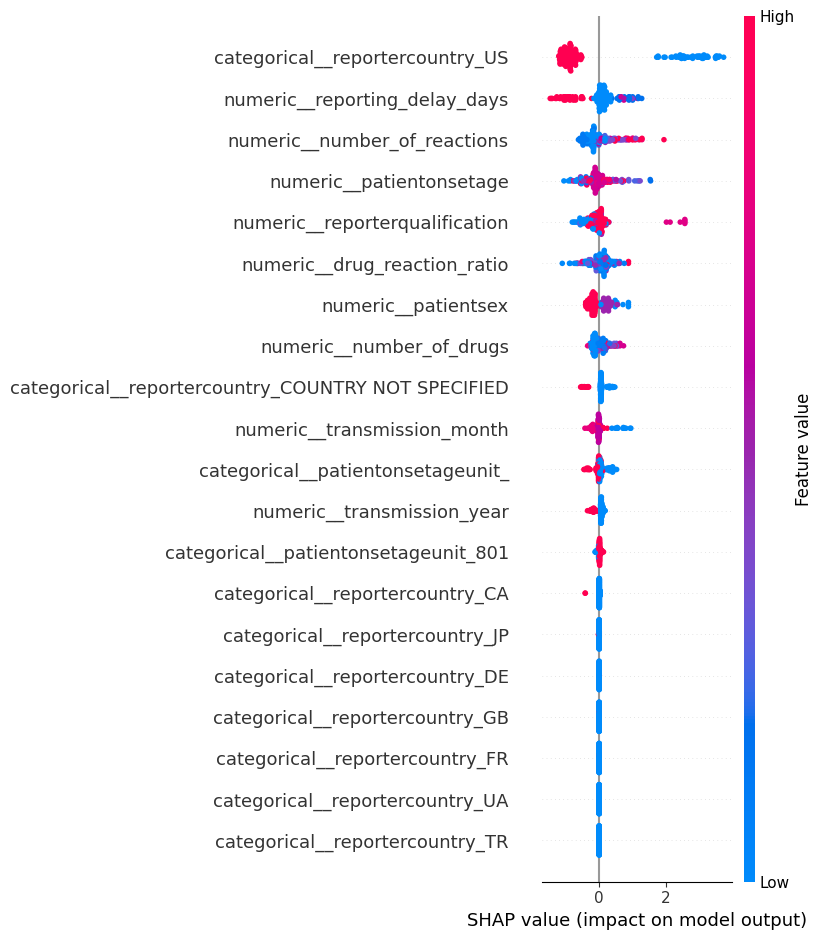

In [0]:
# SHAP tells us how the model used features, not whether those features cause adverse-event seriousness
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)

Isolation Forest

In [0]:
from sklearn.ensemble import IsolationForest

isolation_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", IsolationForest(
        n_estimators=200,
        contamination=0.05,
        random_state=42,
        n_jobs=-1
    ))
])

isolation_model.fit(X_train)

anomaly_prediction = isolation_model.predict(X_test)

anomaly_score = isolation_model.named_steps["model"].decision_function(
    isolation_model.named_steps["preprocessor"].transform(X_test)
)

anomaly_results = X_test.copy()

anomaly_results["anomaly_prediction"] = anomaly_prediction
anomaly_results["anomaly_score"] = anomaly_score

anomaly_results["is_anomaly"] = (
    anomaly_results["anomaly_prediction"] == -1
)

print(
    "Anomalies detected:",
    anomaly_results["is_anomaly"].sum()
)

display(
    anomaly_results
    .sort_values("anomaly_score")
    .head(10)
)

Anomalies detected: 10


patientonsetage,patientonsetageunit,patientsex,reportercountry,reporterqualification,number_of_reactions,number_of_drugs,transmission_year,transmission_month,reporting_delay_days,drug_reaction_ratio,anomaly_prediction,anomaly_score,is_anomaly
null,,2.0,COUNTRY NOT SPECIFIED,5.0,4,2,2018,3,1469,0.5,-1,-0.08542609187199879,true
38.0,801,1.0,GB,3.0,10,3,2016,3,723,0.3,-1,-0.050432794671893766,true
null,,null,US,5.0,2,8,2018,5,1518,4.0,-1,-0.04901088248851293,true
74.0,801,1.0,SE,1.0,2,6,2018,3,1469,3.0,-1,-0.048141492559522714,true
62.0,801,1.0,CN,3.0,1,1,2015,3,379,1.0,-1,-0.0407216190634172,true
null,,2.0,COUNTRY NOT SPECIFIED,5.0,3,8,2015,5,442,2.6666666666666665,-1,-0.02588682559518668,true
42.0,801,1.0,COUNTRY NOT SPECIFIED,5.0,6,1,2015,3,379,0.16666666666666666,-1,-0.013713999355155215,true
null,,2.0,COUNTRY NOT SPECIFIED,5.0,2,1,2015,5,442,0.5,-1,-0.008127076236229491,true
69.0,801,1.0,JP,3.0,2,2,2015,3,379,1.0,-1,-0.006020037297946146,true
68.0,801,2.0,AU,1.0,7,16,2014,10,204,2.2857142857142856,-1,-0.002511634380243599,true


MLflow Experiment Tracking

In [0]:
import mlflow

print("MLflow version: ", mlflow.__version__)

MLflow version:  3.8.1


In [0]:
with mlflow.start_run(run_name="openfda_xgboost_baseline"):

    mlflow.log_params({
        "model": "XGBoost",
        "n_estimators": 200,
        "max_depth": 5,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "random_state": 42
    })

    mlflow.log_metrics({
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc
    })

    print("MLflow run logged.")

MLflow run logged.


Save the Model Output

In [0]:
ml_results = df.loc[X_test.index, ["safetyreportid"]].copy()

ml_results["actual_serious"] = y_test.values
ml_results["predicted_serious"] = xgb_pred
ml_results["predicted_probability"] = xgb_prob

display(ml_results.head(10))

safetyreportid,actual_serious,predicted_serious,predicted_probability
10004170,1,1,0.5010936
10003987,0,0,0.13284644
10003952,1,0,0.4744376
10003601,0,0,0.19056003
10004152,1,1,0.97840196
10003926,1,0,0.26425228
10003792,1,1,0.9257659
10003434,0,0,0.05613183
10003665,0,0,0.18527436
10004028,0,0,0.46103808


In [0]:
output_path = "/Volumes/workspace/default/openfda_ml/openfda_ml_predictions.parquet"

ml_results.to_parquet(
    output_path,
    index=False
)

print("Saved: ", output_path)

Saved:  /Volumes/workspace/default/openfda_ml/openfda_ml_predictions.parquet
